In [1]:
import os
import pandas as pd
import json
import numpy as np

from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.decomposition import PCA
from sklearn.decomposition import TruncatedSVD


from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB, CategoricalNB, BernoulliNB
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, ClassifierMixin

import warnings
warnings.filterwarnings('ignore')

In [2]:
OUTPUT_DIR = os.path.join("output_charts2")
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Charts will be saved to: {OUTPUT_DIR}")

Charts will be saved to: output_charts2


In [3]:
file_path = os.path.join("..","processed_data", "encoded_ai_company_adoption.csv")
df = pd.read_csv(file_path)

meta_path = os.path.join("..","processed_data", "meta_data.json")

orig_data_path = os.path.join("..","data", "ai_company_adoption.csv")
orig_df = pd.read_csv(orig_data_path)

df.head()

,survey_year,company_size,num_employees,annual_revenue_usd_millions,company_age,ai_adoption_rate,ai_adoption_stage,years_using_ai,num_ai_tools_used,ai_projects_active,...,ai_primary_tool_Other,ai_use_case_Fraud Detection,ai_use_case_HR Automation,ai_use_case_Marketing Automation,ai_use_case_Medical Diagnostics,ai_use_case_Predictive Maintenance,ai_use_case_Software Development,ai_use_case_Supply Chain Optimization,cost_reduction_percent,customer_satisfaction
0,2023,0,57,48.31,29,30.57,1,3,1,3,...,0,0,0,0,0,0,0,0,9.45,5.20
1,2023,0,57,48.31,29,27.25,1,4,3,0,...,0,0,0,0,0,0,1,0,0.00,6.98
2,2023,0,57,48.31,29,31.54,1,2,3,3,...,0,0,1,0,0,0,0,0,9.74,4.12
3,2023,0,57,48.31,29,11.02,1,2,1,2,...,0,0,0,0,0,0,1,0,0.00,5.72
4,2024,0,57,48.31,30,33.39,1,7,3,5,...,0,0,0,0,0,0,0,0,9.02,6.31


In [ ]:
target_col = 'ai_failure_rate'

# Phân cụm y theo Qcut

In [ ]:
n_bins = 4
df['qcut_class'], qcut_thresholds = pd.qcut(df[target_col], q=n_bins, labels=False, retbins=True)

qcut_summary = df.groupby('qcut_class')[target_col].agg(['count', 'min', 'max']).sort_values('min')
print(qcut_summary)

            count    min    max
qcut_class                     
0           37517   0.00  20.27
1           37543  20.28  25.88
2           37457  25.89  31.52
3           37483  31.53  40.00


Kết luận: Dùng Q-cut là hợp lí nhất.

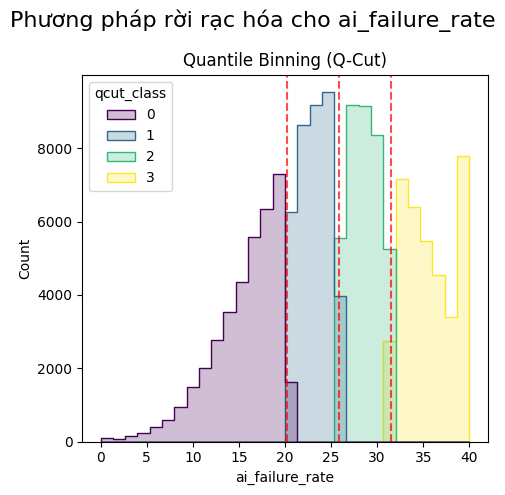

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
fig.suptitle('Phương pháp rời rạc hóa cho ai_failure_rate', fontsize=16)

# Màu sắc phân biệt cho các cụm
palette = 'viridis'

# Q-Cut
sns.histplot(data=df, x=target_col, hue='qcut_class', palette=palette, element='step', ax=ax, bins=30)
ax.set_title('Quantile Binning (Q-Cut)')
for t in qcut_thresholds[1:-1]: 
    ax.axvline(t, color='red', linestyle='--', alpha=0.7)

plt.tight_layout()
os.makedirs(OUTPUT_DIR, exist_ok=True)
plt.savefig(os.path.join(OUTPUT_DIR, "01_qcut_distribution.png"), bbox_inches="tight", dpi=150)
plt.show()

In [ ]:
with open(meta_path, "r", encoding="utf-8") as f:
    meta_data = json.load(f)
    
    NUMERIC_ORDINAL_COLS = meta_data["numeric_ordinal_cols"]
    ONEHOT_COLS = meta_data["onehot_cols"]
    CYCLIC_COLS = meta_data["cyclic_cols"]
    BINARY_COLS = meta_data["binary_cols"]

if 'ai_failure_rate' in NUMERIC_ORDINAL_COLS:
    NUMERIC_ORDINAL_COLS.remove('ai_failure_rate')

In [ ]:
X = df.drop(columns=['ai_failure_rate', 'qcut_class'], errors='ignore')
y = df['qcut_class']
X.shape, y.shape

((150000, 86), (150000,))

*Chuẩn hóa*

In [ ]:
def preprocess_data(X_train, X_test):
    valid_num_cols = [col for col in NUMERIC_ORDINAL_COLS if col in X_train.columns]
    valid_cat_cols = [col for col in ONEHOT_COLS if col in X_train.columns]
    valid_cyc_cols = [col for col in CYCLIC_COLS if col in X_train.columns]

    scaler = StandardScaler()
    X_train_num = scaler.fit_transform(X_train[valid_num_cols].astype(float))
    X_test_num = scaler.transform(X_test[valid_num_cols].astype(float))

    X_train_cat = X_train[valid_cat_cols].astype(float).values
    X_test_cat = X_test[valid_cat_cols].astype(float).values

    train_col_means = X_train_cat.mean(axis=0)
    train_col_means = np.where(train_col_means == 0, 1e-8, train_col_means)

    X_train_cat_scaled = X_train_cat / np.sqrt(train_col_means)
    X_test_cat_scaled = X_test_cat / np.sqrt(train_col_means)

    X_train_cyc = X_train[valid_cyc_cols].astype(float).values
    X_test_cyc = X_test[valid_cyc_cols].astype(float).values

    X_train_combined = np.hstack([X_train_num, X_train_cat_scaled, X_train_cyc])
    X_test_combined = np.hstack([X_test_num, X_test_cat_scaled, X_test_cyc])

    return X_train_combined, X_test_combined

*Kiểm tra lượng thông tin được giữ lại sau khi giảm chiều*

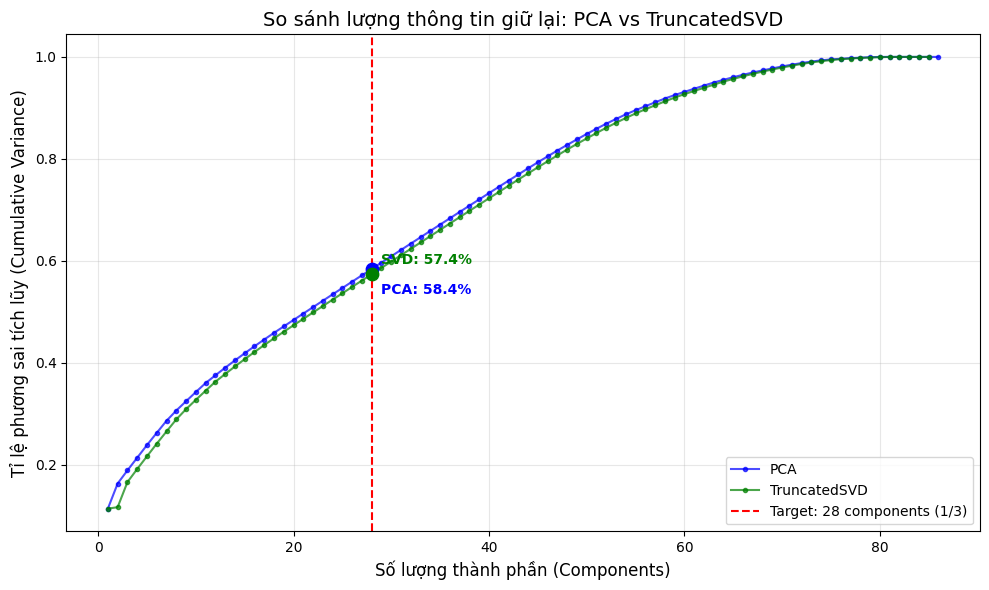

In [ ]:
def plot_cumulative_variance_comparison(X_scaled, n_features_original):
    target_components = n_features_original // 3
    
    # 1. PCA
    pca_full = PCA(random_state=42)
    pca_full.fit(X_scaled)
    pca_cumulative_var = np.cumsum(pca_full.explained_variance_ratio_)
    pca_retained_at_target = pca_cumulative_var[target_components - 1]

    # 2. TruncatedSVD
    # components < n_features
    svd_full = TruncatedSVD(n_components=n_features_original - 1, random_state=42)
    svd_full.fit(X_scaled)
    svd_cumulative_var = np.cumsum(svd_full.explained_variance_ratio_)
    svd_retained_at_target = svd_cumulative_var[target_components - 1]

    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(pca_cumulative_var) + 1), pca_cumulative_var, 
             marker='.', linestyle='-', color='blue', alpha=0.7, label='PCA')
    
    plt.plot(range(1, len(svd_cumulative_var) + 1), svd_cumulative_var, 
             marker='.', linestyle='-', color='green', alpha=0.7, label='TruncatedSVD')
    
    plt.axvline(x=target_components, color='red', linestyle='--', 
                label=f'Target: {target_components} components (1/3)')
    
    plt.scatter([target_components], [pca_retained_at_target], color='blue', s=80, zorder=5)
    plt.scatter([target_components], [svd_retained_at_target], color='green', s=80, zorder=5)
    
    plt.text(target_components + 1, pca_retained_at_target - 0.05, 
             f'PCA: {pca_retained_at_target*100:.1f}%', color='blue', fontweight='bold')
    plt.text(target_components + 1, svd_retained_at_target + 0.02, 
             f'SVD: {svd_retained_at_target*100:.1f}%', color='green', fontweight='bold')

    plt.title('So sánh lượng thông tin giữ lại: PCA vs TruncatedSVD', fontsize=14)
    plt.xlabel('Số lượng thành phần (Components)', fontsize=12)
    plt.ylabel('Tỉ lệ phương sai tích lũy (Cumulative Variance)', fontsize=12)
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    plt.savefig(os.path.join(OUTPUT_DIR, "02_cumulative_variance_pca_svd.png"), bbox_inches="tight", dpi=150)
    plt.show()

X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_train_combined, X_test_combined = preprocess_data(X_train_temp, X_test_temp)

plot_cumulative_variance_comparison(X_train_combined, n_features_original=X.shape[1])

*Tính toán số dòng dữ liệu tương ứng theo company_id để phù hợp với các test size*

In [ ]:
unique_companies = orig_df['company_id'].unique()
total_companies = len(unique_companies)
print(f"Tổng số công ty trong dữ liệu gốc: {total_companies}")

train_proportions = [0.8, 0.7, 0.6]

split_indices = {}

for prop in train_proportions:
    n_train_companies = int(total_companies * prop)
    first_test_company_id = unique_companies[n_train_companies]

    split_idx = orig_df[orig_df['company_id'] == first_test_company_id].index[0]
    split_indices[prop] = split_idx

    train_pct = int(round(prop * 100))
    test_pct = 100 - train_pct
    print(f"Tỷ lệ {train_pct}/{test_pct}:")
    print(f"  + Số công ty trong Train: {n_train_companies}")
    print(f"  + ID công ty đầu tiên của tập Test: {first_test_company_id}")
    print(f"  => Cần cắt dữ liệu ở dòng Index thứ: {split_idx}\n")

Tổng số công ty trong dữ liệu gốc: 10000
Tỷ lệ 80/20:
  + Số công ty trong Train: 8000
  + ID công ty đầu tiên của tập Test: COMP-08001
  => Cần cắt dữ liệu ở dòng Index thứ: 120093

Tỷ lệ 70/30:
  + Số công ty trong Train: 7000
  + ID công ty đầu tiên của tập Test: COMP-07001
  => Cần cắt dữ liệu ở dòng Index thứ: 105072

Tỷ lệ 60/40:
  + Số công ty trong Train: 6000
  + ID công ty đầu tiên của tập Test: COMP-06001
  => Cần cắt dữ liệu ở dòng Index thứ: 90048



# Áp dụng mô hình với GaussianNB (baseline)

### Kết quả mô hình

In [ ]:
def run_gnb_baseline_experiment(X_data, y_data, method='Original'):
    results = []
    
    # Tìm số chiều sau khi giảm 1/3 số chiều ban đầu 
    n_features_original = X_data.shape[1]
    target_components = max(1, n_features_original // 3)

    for split, train_size in split_indices.items():
        split_label = f"{int((split)*10)}:{int(10 - split*10)}"

        # 1. Chia train/test
        X_train, X_test, y_train, y_test = train_test_split(
            X_data, y_data, train_size=train_size, shuffle = False
        )

        # 2. Chuẩn hóa 
        X_train_combined, X_test_combined = preprocess_data(X_train, X_test)

        # 3. Giảm chiều 
        if method.upper() == 'ORIGINAL':
            X_train_final, X_test_final = X_train_combined, X_test_combined
            data_type_name = 'Original'

        elif method.upper() == 'PCA':
            reducer = PCA(n_components=target_components, random_state=42)
            X_train_final = reducer.fit_transform(X_train_combined)
            X_test_final  = reducer.transform(X_test_combined)
            data_type_name = f'PCA ({target_components}D)'

        elif method.upper() == 'SVD':
            reducer = TruncatedSVD(n_components=target_components, random_state=42)
            X_train_final = reducer.fit_transform(X_train_combined)
            X_test_final  = reducer.transform(X_test_combined)
            data_type_name = f'TruncatedSVD ({target_components}D)'
        
        elif method.upper() == 'LDA':
            lda_components = min(target_components, len(np.unique(y_data)) - 1)
            reducer = LinearDiscriminantAnalysis(n_components=lda_components)
            X_train_final = reducer.fit_transform(X_train_combined, y_train)
            X_test_final  = reducer.transform(X_test_combined)
            data_type_name = f'LDA ({lda_components}D)'

        else:
            raise ValueError("method chỉ hỗ trợ 'Original', 'PCA' hoặc 'SVD'")

        # 4. Model - GaussianNB
        y_train_arr = y_train.values if hasattr(y_train, 'values') else y_train

        model = GaussianNB()
        model.fit(X_train_final, y_train_arr)
        
        y_train_pred = model.predict(X_train_final)
        y_test_pred  = model.predict(X_test_final)

        # 5. Đánh giá 
        train_acc = accuracy_score(y_train, y_train_pred)
        test_acc  = accuracy_score(y_test, y_test_pred)
        
        test_f1   = f1_score(y_test, y_test_pred, average='macro')
        test_precision = precision_score(y_test, y_test_pred, average='macro', zero_division=0)
        test_recall    = recall_score(y_test, y_test_pred, average='macro', zero_division=0)
        cm = confusion_matrix(y_test, y_test_pred)

        results.append({
            'Data Type':          data_type_name,
            'Split (Train:Test)': split_label,
            'Train Acc':          train_acc,
            'Test Acc':           test_acc,
            'Gap Acc':            train_acc - test_acc,
            'Test Precision':     test_precision,
            'Test Recall':        test_recall,
            'Test F1':            test_f1,
            'Confusion Matrix':   cm,

            'Model Object':       model,
            'X_train_raw':        X_train, 
            'X_test_raw':         X_test,  
            'y_test_actual':      y_test,
            'y_test_pred':        y_test_pred,
            'y_train_actual':     y_train,
            'y_train_pred':       y_train_pred
        })

    return results

In [ ]:
results_orig = run_gnb_baseline_experiment(X, y, method='Original')
results_pca = run_gnb_baseline_experiment(X, y, method='PCA')
results_svd = run_gnb_baseline_experiment(X, y, method='SVD')
results_lda = run_gnb_baseline_experiment(X, y, method='LDA')

all_results = results_orig + results_pca + results_svd + results_lda
df_results = pd.DataFrame(all_results)
display(df_results.drop(columns=['Confusion Matrix','Model Object', 'X_train_raw', 'X_test_raw', 'y_test_actual', 'y_test_pred', 'y_train_actual', 'y_train_pred']))

,Data Type,Split (Train:Test),Train Acc,Test Acc,Gap Acc,Test Precision,Test Recall,Test F1
0,Original,8:2,0.484949,0.481860,0.003089,0.457502,0.481170,0.461556
1,Original,7:3,0.483744,0.481526,0.002218,0.457757,0.480186,0.461376
2,Original,6:4,0.483453,0.482603,0.000851,0.458608,0.481772,0.462489
3,PCA (28D),8:2,0.464881,0.466346,-0.001464,0.446560,0.465802,0.450225
4,PCA (28D),7:3,0.462864,0.466079,-0.003215,0.446729,0.464907,0.450290
5,PCA (28D),6:4,0.461609,0.464722,-0.003112,0.444815,0.464002,0.448749
6,TruncatedSVD (28D),8:2,0.468953,0.467750,0.001203,0.448260,0.467206,0.451967
7,TruncatedSVD (28D),7:3,0.466556,0.467325,-0.000769,0.448051,0.466153,0.451500
8,TruncatedSVD (28D),6:4,0.465963,0.466773,-0.000811,0.446706,0.466050,0.450729
9,LDA (3D),8:2,0.532529,0.533320,-0.000791,0.529799,0.532963,0.526927


### Confusion Matrix

In [ ]:
def plot_confusion_matrix(cm, classes, title):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.title(title, fontsize=14)
    plt.ylabel('Thực tế (Actual)', fontsize=12)
    plt.xlabel('Dự đoán (Predicted)', fontsize=12)
    plt.tight_layout()
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    filename = f"confusion_matrix_{title.replace(' ', '_').replace('(', '').replace(')', '').replace(':', '')}.png"
    plt.savefig(os.path.join(OUTPUT_DIR, filename), bbox_inches="tight", dpi=150)
    plt.show()

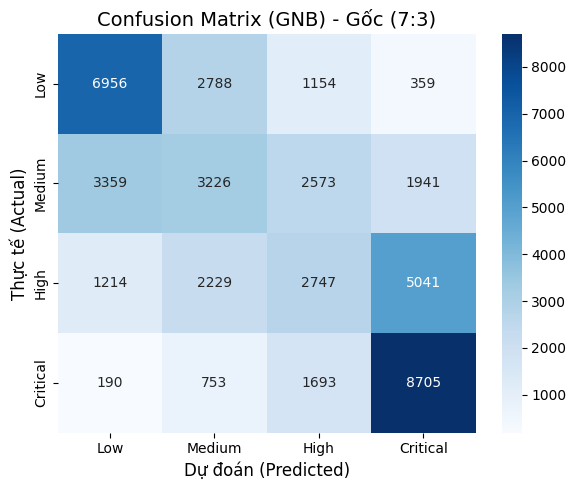

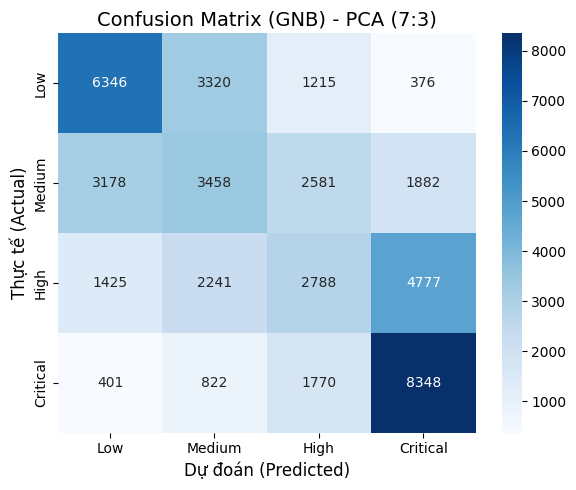

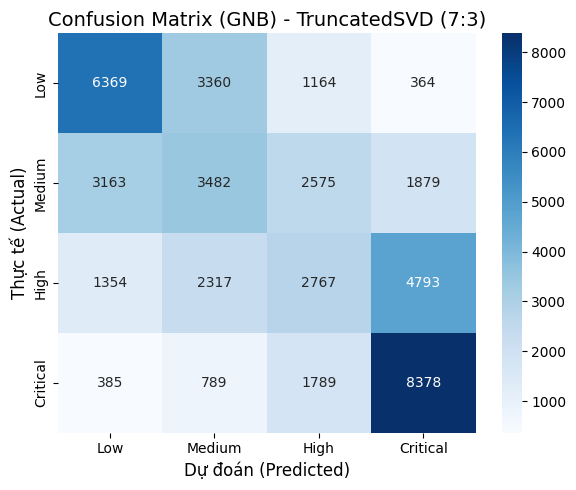

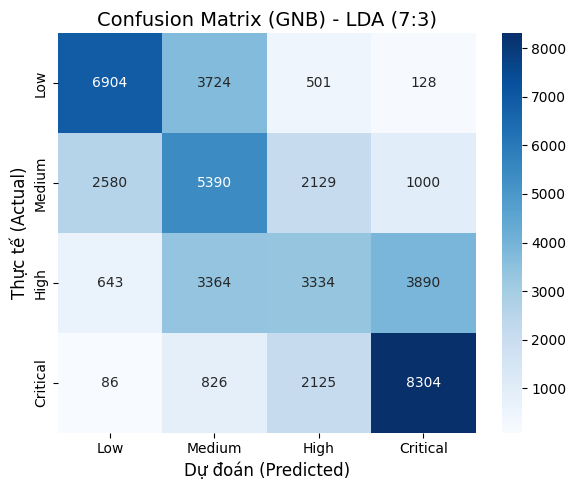

In [ ]:
labels_4_classes = ['Low', 'Medium', 'High', 'Critical'] 

# Tương ứng với slpit 7:3
cm_orig = results_orig[1]['Confusion Matrix']
cm_pca = results_pca[1]['Confusion Matrix']
cm_svd = results_svd[1]['Confusion Matrix']
cm_lda = results_lda[1]['Confusion Matrix']

plot_confusion_matrix(cm_orig, labels_4_classes, title='Confusion Matrix (GNB) - Gốc (7:3)')

plot_confusion_matrix(cm_pca, labels_4_classes, title='Confusion Matrix (GNB) - PCA (7:3)')

plot_confusion_matrix(cm_svd, labels_4_classes, title='Confusion Matrix (GNB) - TruncatedSVD (7:3)')

plot_confusion_matrix(cm_lda, labels_4_classes, title='Confusion Matrix (GNB) - LDA (7:3)')

### So sánh các tham số, kiểm tra overfit

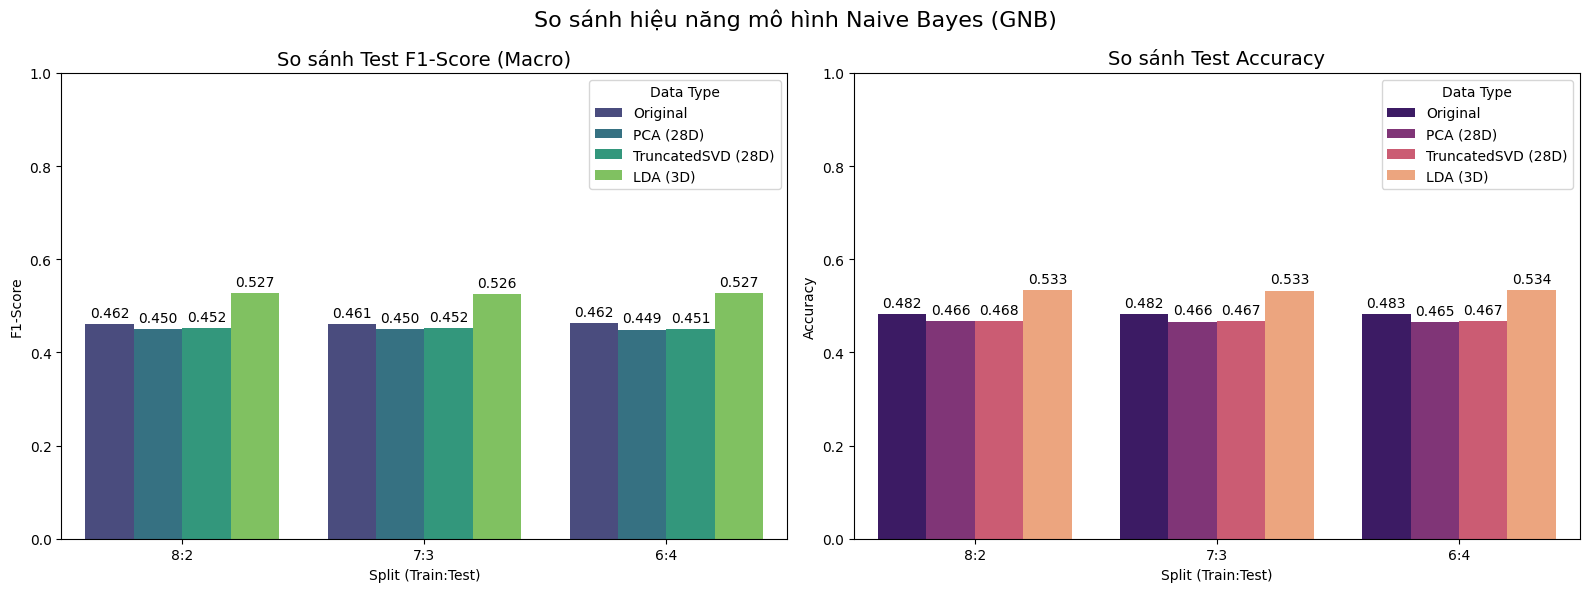

In [ ]:
def plot_nb_classification_results(df_results, type):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    if type == 'GNB':
        fig.suptitle('So sánh hiệu năng mô hình Naive Bayes (GNB)', fontsize=16)
    elif type == 'CNB':
        fig.suptitle('So sánh hiệu năng mô hình Naive Bayes (CNB)', fontsize=16)
    else:
        fig.suptitle('So sánh hiệu năng mô hình Naive Bayes (MNB)', fontsize=16)

    sns.barplot(data=df_results, x='Split (Train:Test)', y='Test F1', hue='Data Type', ax=axes[0], palette='viridis')
    axes[0].set_title('So sánh Test F1-Score (Macro)', fontsize=14)
    axes[0].set_ylabel('F1-Score')
    axes[0].set_ylim(0, 1)

    sns.barplot(data=df_results, x='Split (Train:Test)', y='Test Acc', hue='Data Type', ax=axes[1], palette='magma')
    axes[1].set_title('So sánh Test Accuracy', fontsize=14)
    axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim(0, 1)

    for ax in axes:
        for container in ax.containers:
            ax.bar_label(container, fmt='%.3f', padding=3, size=10)

    plt.tight_layout()
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    plt.savefig(os.path.join(OUTPUT_DIR, f"classification_results_{type}.png"), bbox_inches="tight", dpi=150)
    plt.show()

plot_nb_classification_results(df_results, 'GNB')

*Kiểm tra overfit*

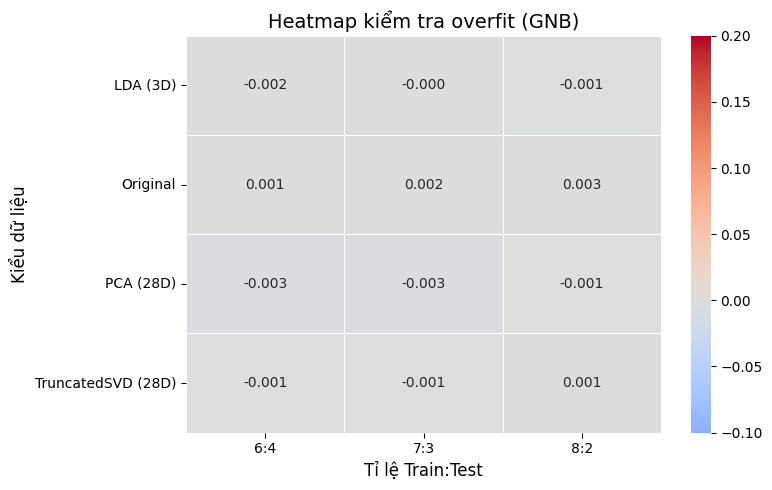

In [ ]:
def plot_nb_gap_heatmap(df_results, type):
    gap_pivot = df_results.pivot(
        index='Data Type',
        columns='Split (Train:Test)',
        values='Gap Acc'
    )

    plt.figure(figsize=(8, 5))

    sns.heatmap(
        gap_pivot,
        annot=True,
        fmt='.3f',
        cmap='coolwarm',
        linewidths=0.5,
        center=0,
        vmin=-0.1,
        vmax=0.2
    )

    if type == 'GNB':
        plt.title('Heatmap kiểm tra overfit (GNB)', fontsize=14)
    elif type == 'CNB':
        plt.title('Heatmap kiểm tra overfit (CNB)', fontsize=14)
    else:
        plt.title('Heatmap kiểm tra overfit (MNB)', fontsize=14)

    #plt.title('Heatmap kiểm tra overfit (GNB)', fontsize=14)
    plt.ylabel('Kiểu dữ liệu', fontsize=12)
    plt.xlabel('Tỉ lệ Train:Test', fontsize=12)

    plt.tight_layout()
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    plt.savefig(os.path.join(OUTPUT_DIR, f"gap_heatmap_{type}.png"), bbox_inches="tight", dpi=150)
    plt.show()

plot_nb_gap_heatmap(df_results, 'GNB')

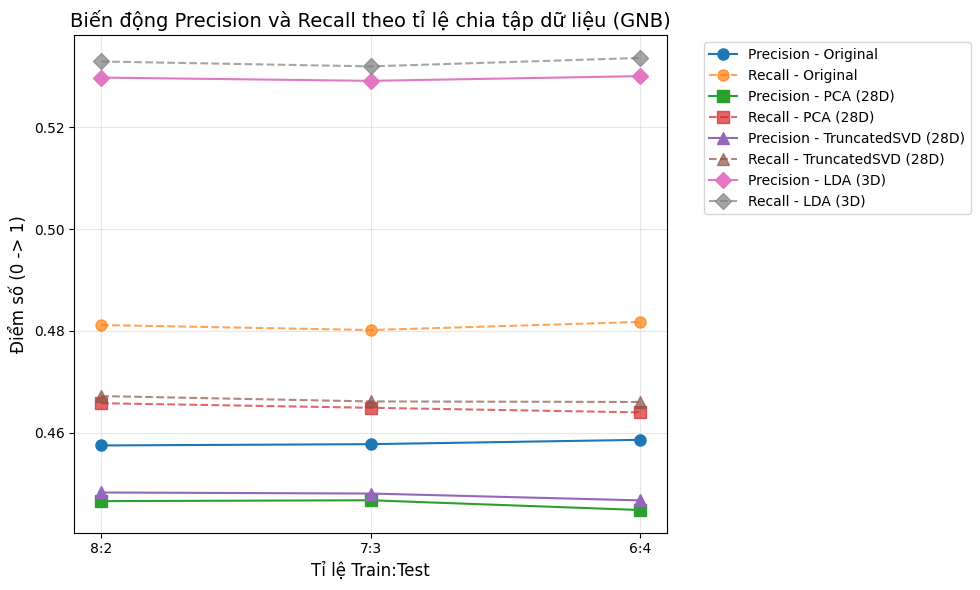

In [ ]:
def plot_precision_recall_trends(df_results, type):
    plt.figure(figsize=(10, 6))

    unique_data_types = df_results['Data Type'].unique()
    available_markers = ['o', 's', '^', 'D', 'v', '<', '>']
    
    markers = {dtype: available_markers[i % len(available_markers)] 
               for i, dtype in enumerate(unique_data_types)}

    data_types = df_results['Data Type'].unique()

    for dt in data_types:
        subset = df_results[df_results['Data Type'] == dt]
        m = markers.get(dt, 'o')

        # Precision (Đường nét liền)
        plt.plot(
            subset['Split (Train:Test)'],
            subset['Test Precision'],
            marker=m,
            linestyle='-',
            markersize=8,
            label=f'Precision - {dt}'
        )

        # Recall (Đường nét đứt)
        plt.plot(
            subset['Split (Train:Test)'],
            subset['Test Recall'],
            marker=m,
            linestyle='--',
            markersize=8,
            alpha=0.7,
            label=f'Recall - {dt}'
        )
    if type == 'GNB':
        plt.title('Biến động Precision và Recall theo tỉ lệ chia tập dữ liệu (GNB)', fontsize=14)
    elif type == 'CNB':
        plt.title('Biến động Precision và Recall theo tỉ lệ chia tập dữ liệu (CNB)', fontsize=14)
    else:
        plt.title('Biến động Precision và Recall theo tỉ lệ chia tập dữ liệu (MNB)', fontsize=14)

    #plt.title('Biến động Precision và Recall theo tỉ lệ chia tập dữ liệu', fontsize=14)
    plt.xlabel('Tỉ lệ Train:Test', fontsize=12)
    plt.ylabel('Điểm số (0 -> 1)', fontsize=12)

    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    plt.savefig(os.path.join(OUTPUT_DIR, f"precision_recall_trends_{type}.png"), bbox_inches="tight", dpi=150)
    plt.show()

plot_precision_recall_trends(df_results, 'GNB')

### Hiệu chỉnh

*Thử hiệu chỉnh khi thay đổi var_smoothing*

In [ ]:
def run_gnb_baseline_with_tuning(X_data, y_data, method='Original'):
    results = []
    
    n_features_original = X_data.shape[1]
    target_components = max(1, n_features_original // 3)

    # var_smoothing (từ 10^-10 đến 10^-1)
    param_grid = {'var_smoothing': np.logspace(-10, -1, num=50)}

    for split, train_size in split_indices.items():
        split_label = f"{int((split)*10)}:{int(10 - split*10)}"

        X_train, X_test, y_train, y_test = train_test_split(
            X_data, y_data, train_size=train_size, shuffle = False
        )

        X_train_combined, X_test_combined = preprocess_data(X_train, X_test)

        retained_variance = 1.0
        if method.upper() == 'ORIGINAL':
            X_train_final, X_test_final = X_train_combined, X_test_combined
            data_type_name = 'Original'

        elif method.upper() == 'PCA':
            reducer = PCA(n_components=target_components, random_state=42)
            X_train_final = reducer.fit_transform(X_train_combined)
            X_test_final  = reducer.transform(X_test_combined)
            retained_variance = reducer.explained_variance_ratio_.sum()
            data_type_name = f'PCA ({target_components}D)'

        elif method.upper() == 'SVD':
            reducer = TruncatedSVD(n_components=target_components, random_state=42)
            X_train_final = reducer.fit_transform(X_train_combined)
            X_test_final  = reducer.transform(X_test_combined)
            retained_variance = reducer.explained_variance_ratio_.sum()
            data_type_name = f'TruncatedSVD ({target_components}D)'

        elif method.upper() == 'LDA':
            lda_components = min(target_components, len(np.unique(y_data)) - 1)
            reducer = LinearDiscriminantAnalysis(n_components=lda_components)
            X_train_final = reducer.fit_transform(X_train_combined, y_train)
            X_test_final  = reducer.transform(X_test_combined)
            data_type_name = f'LDA ({lda_components}D)'
            #tránh nhầm với PCA
            retained_variance = None

        # Tinh chỉnh siêu tham số 
        y_train_arr = y_train.values if hasattr(y_train, 'values') else y_train
        
        grid_search = GridSearchCV(
            GaussianNB(), 
            param_grid, 
            cv=5, 
            scoring='f1_macro', 
            n_jobs=-1
        )
        grid_search.fit(X_train_final, y_train_arr)
        
        best_model = grid_search.best_estimator_
        best_var_smoothing = grid_search.best_params_['var_smoothing']

        # Mô hình và đánh giá  
        y_train_pred = best_model.predict(X_train_final)
        y_test_pred  = best_model.predict(X_test_final)

        train_acc = accuracy_score(y_train, y_train_pred)
        test_acc  = accuracy_score(y_test, y_test_pred)
        test_f1   = f1_score(y_test, y_test_pred, average='macro')
        test_precision = precision_score(y_test, y_test_pred, average='macro', zero_division=0)
        test_recall    = recall_score(y_test, y_test_pred, average='macro', zero_division=0)
        cm = confusion_matrix(y_test, y_test_pred)

        results.append({
            'Data Type':          data_type_name,
            'Split (Train:Test)': split_label,
            'Retained Var':       retained_variance,
            'Best Var Smoothing': best_var_smoothing, 
            'Train Acc':          train_acc,
            'Test Acc':           test_acc,
            'Gap Acc':            train_acc - test_acc,
            'Test Precision':     test_precision,
            'Test Recall':        test_recall,
            'Test F1':            test_f1,
            'Confusion Matrix':   cm
        })

    return results

df_results_tuned = pd.DataFrame(
    run_gnb_baseline_with_tuning(X, y, 'Original') + 
    run_gnb_baseline_with_tuning(X, y, 'PCA') + 
    run_gnb_baseline_with_tuning(X, y, 'SVD') + 
    run_gnb_baseline_with_tuning(X, y, 'LDA')
)
display(df_results_tuned.drop(columns=['Confusion Matrix']))

,Data Type,Split (Train:Test),Retained Var,Best Var Smoothing,Train Acc,Test Acc,Gap Acc,Test Precision,Test Recall,Test F1
0,Original,8:2,1.000000,0.012068,0.484658,0.481660,0.002998,0.457383,0.480973,0.461400
1,Original,7:3,1.000000,0.002223,0.483668,0.481548,0.002120,0.457807,0.480209,0.461417
2,Original,6:4,1.000000,0.002223,0.483420,0.482603,0.000817,0.458610,0.481772,0.462479
3,PCA (28D),8:2,0.584212,0.100000,0.470544,0.472130,-0.001587,0.454653,0.471676,0.454923
4,PCA (28D),7:3,0.584364,0.100000,0.469659,0.471644,-0.001985,0.455807,0.470441,0.455236
5,PCA (28D),6:4,0.584631,0.100000,0.467939,0.471444,-0.003505,0.454573,0.470689,0.455268
6,TruncatedSVD (28D),8:2,0.571988,0.100000,0.471343,0.474036,-0.002693,0.456810,0.473581,0.457012
7,TruncatedSVD (28D),7:3,0.572089,0.100000,0.471153,0.472512,-0.001358,0.456253,0.471329,0.455667
8,TruncatedSVD (28D),6:4,0.572277,0.100000,0.469283,0.473829,-0.004546,0.456879,0.473092,0.457145
9,LDA (3D),8:2,NaN,0.018421,0.532637,0.533587,-0.000950,0.530319,0.533237,0.527196


### Trực quan hóa tương quan giữa thực tế và dự đoán

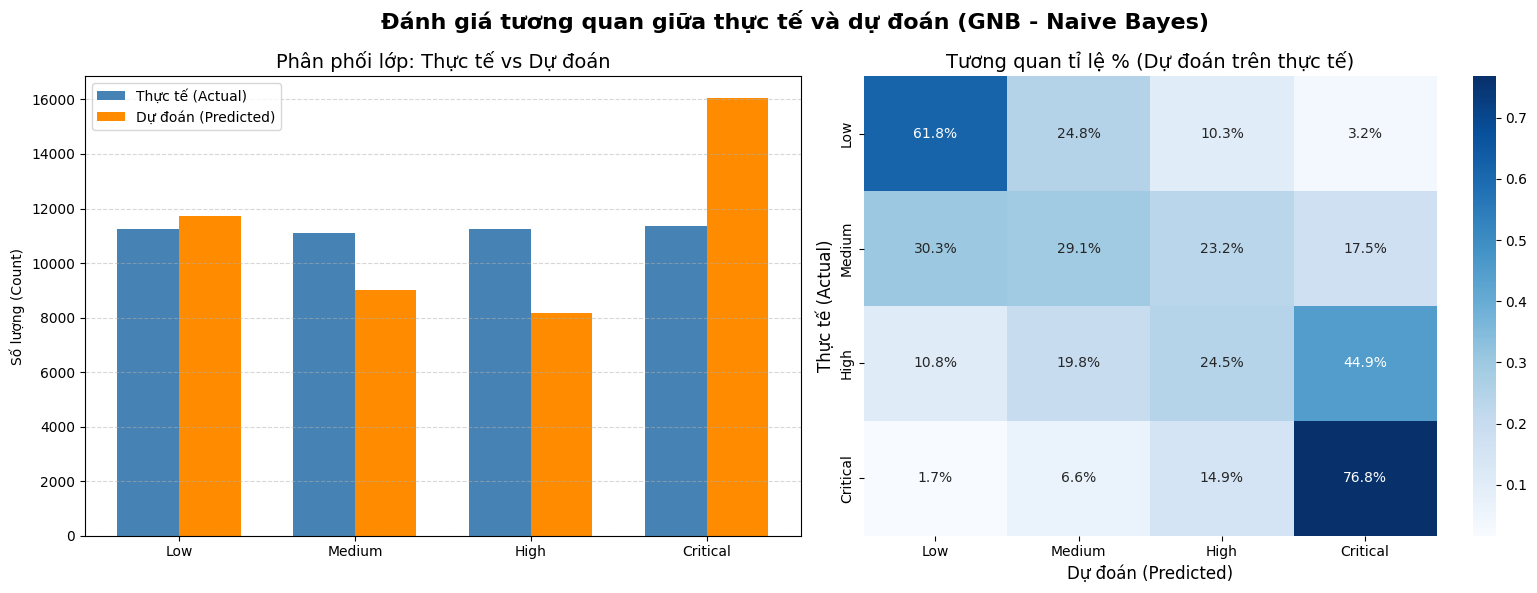

In [ ]:
def plot_nb_prediction_analysis(results_orig, type):
    best_result = results_orig[1]

    y_actual = best_result['y_test_actual']
    y_pred = best_result['y_test_pred']

    labels_4_classes = ['Low', 'Medium', 'High', 'Critical']

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    if type == 'GNB':
        fig.suptitle(
        'Đánh giá tương quan giữa thực tế và dự đoán (GNB - Naive Bayes)',
        fontsize=16,
        fontweight='bold'
    )
    elif type == 'CNB':
        fig.suptitle(
        'Đánh giá tương quan giữa thực tế và dự đoán (CNB - Naive Bayes)',
        fontsize=16,
        fontweight='bold'
    )
    else:
        fig.suptitle(
        'Đánh giá tương quan giữa thực tế và dự đoán (MNB - Naive Bayes)',
        fontsize=16,
        fontweight='bold'
    )

    # So sánh phân phối tổng thể

    # Đếm số lượng thực tế
    actual_counts = (
        pd.Series(y_actual)
        .value_counts()
        .reindex(range(4))
        .fillna(0)
    )

    # Đếm số lượng dự đoán
    pred_counts = (
        pd.Series(y_pred)
        .value_counts()
        .reindex(range(4))
        .fillna(0)
    )

    x = np.arange(len(labels_4_classes))
    width = 0.35

    axes[0].bar(
        x - width / 2,
        actual_counts,
        width,
        label='Thực tế (Actual)',
        color='steelblue'
    )

    axes[0].bar(
        x + width / 2,
        pred_counts,
        width,
        label='Dự đoán (Predicted)',
        color='darkorange'
    )

    axes[0].set_title('Phân phối lớp: Thực tế vs Dự đoán', fontsize=14)

    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels_4_classes)

    axes[0].set_ylabel('Số lượng (Count)')

    axes[0].legend()

    axes[0].grid(axis='y', linestyle='--', alpha=0.5)

    # Ma trận nhầm lẫn chuẩn hóa

    # Chuẩn hóa theo hàng (thực tế) để xem xét tỉ lệ %
    cm = confusion_matrix(y_actual, y_pred)

    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    sns.heatmap(
        cm_normalized,
        annot=True,
        fmt='.1%',
        cmap='Blues',
        xticklabels=labels_4_classes,
        yticklabels=labels_4_classes,
        ax=axes[1]
    )

    axes[1].set_title(
        'Tương quan tỉ lệ % (Dự đoán trên thực tế)',
        fontsize=14
    )

    axes[1].set_ylabel('Thực tế (Actual)', fontsize=12)

    axes[1].set_xlabel('Dự đoán (Predicted)', fontsize=12)

    plt.tight_layout()
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    plt.savefig(os.path.join(OUTPUT_DIR, f"prediction_analysis_{type}.png"), bbox_inches="tight", dpi=150)
    plt.show()

plot_nb_prediction_analysis(results_orig, 'GNB')

# Áp dụng mô hình với CategoricalNB

### Rời rạc hóa các biến đầu vào 

Các ngưỡng chia (Bins edges):
Bin 0: 0.00 -> 6.25
Bin 1: 6.25 -> 8.46
Bin 2: 8.46 -> 10.42
Bin 3: 10.42 -> 12.75
Bin 4: 12.75 -> 25.00


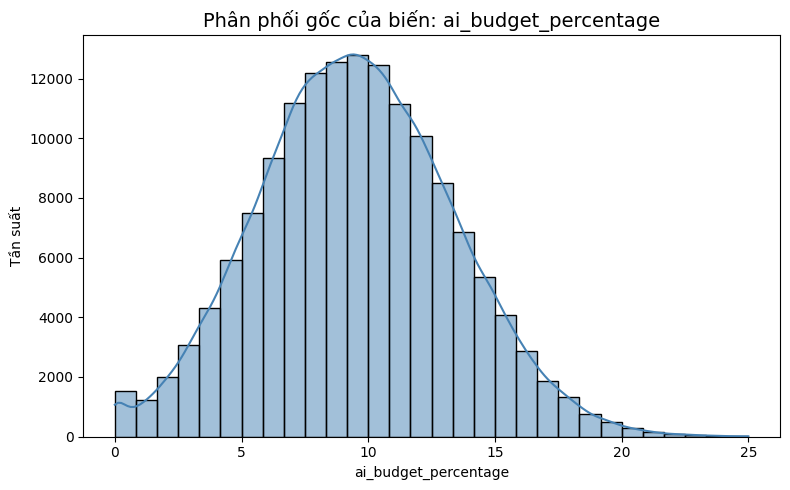

In [ ]:
demo_col = 'ai_budget_percentage'

# Chia thành 5 nhóm (bins) theo tần suất (quantile)
# encode='ordinal' để biến đổi thành số nguyên 0, 1, 2, 3, 4
kbins = KBinsDiscretizer(
    n_bins=5,
    encode='ordinal',
    strategy='quantile'
)

demo_data = df[[demo_col]].dropna()

demo_binned = kbins.fit_transform(demo_data)

df_demo = pd.DataFrame({
    'Gốc (Liên tục)': demo_data[demo_col].values,
    'Rời rạc hóa (Ordinal)': demo_binned.flatten()
})

# Vẽ biểu đồ phân phối gốc
plt.figure(figsize=(8, 5))

plt.title(f'Phân phối gốc của biến: {demo_col}', fontsize=14)

sns.histplot(
    df_demo['Gốc (Liên tục)'],
    bins=30,
    kde=True,
    color='steelblue'
)

plt.xlabel(demo_col)
plt.ylabel('Tần suất')

# In ra các ngưỡng chia
edges = kbins.bin_edges_[0]

print("Các ngưỡng chia (Bins edges):")

for i in range(len(edges) - 1):
    print(f"Bin {i}: {edges[i]:.2f} -> {edges[i+1]:.2f}")

plt.tight_layout()
plt.show()

In [ ]:
CONTINUOUS_COLS = [
    "survey_year",
    "num_employees",
    "annual_revenue_usd_millions",
    "company_age",
    "ai_adoption_rate",
    "years_using_ai",
    "num_ai_tools_used",
    "ai_projects_active",
    "ai_training_hours",
    "ai_budget_percentage",
    "ai_maturity_score",
    "ai_investment_per_employee",
    "regulatory_compliance_score",
    "ai_risk_management_score",
    "remote_work_percentage",
    "employee_satisfaction_score",
    "task_automation_rate",
    "time_saved_per_week",
    "productivity_change_percent",
    "jobs_displaced",
    "jobs_created",
    "reskilled_employees",
    "revenue_growth_percent",
    "cost_reduction_percent",
    "innovation_score",
    "customer_satisfaction"
]

NOMINAL_COLS = [
    'country', 'region', 'industry', 'ai_primary_tool', 'ai_use_case',
]

# Chuyển về nhãn 1, 2, 3, 4 
QUARTER = ["quarter"]

ORDINAL_ALREADY_COLS = [
    "company_size",
    "ai_adoption_stage",
    "data_privacy_level",
]

BINARY_PASS_COLS = ['ai_ethics_committee']

orig_cols = CONTINUOUS_COLS + NOMINAL_COLS + QUARTER
processed_cols = ORDINAL_ALREADY_COLS + BINARY_PASS_COLS

X_orig_part = orig_df[orig_cols]
X_processed_part = df[processed_cols]

X_raw = pd.concat([X_orig_part, X_processed_part], axis=1)
y = df['qcut_class'].values

print(f"Shape X_raw: {X_raw.shape}, Shape y: {y.shape}")

Shape X_raw: (150000, 36), Shape y: (150000,)


In [ ]:
def auto_bins_fd(series: pd.Series, max_bins: int = 10) -> int:
    clean_data = series.dropna()
    if len(clean_data) == 0:
        return 2
    data = clean_data.to_numpy()
    n_samples = len(data)

    data_min = data.min()
    data_max = data.max()
    data_range = data_max - data_min

    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1

    if iqr == 0:
        estimated_bins = int(np.ceil(np.log2(n_samples) + 1))
    else:

        bin_width = 2 * iqr * (n_samples ** (-1 / 3))
        estimated_bins = int(np.ceil(data_range / bin_width))

    n_unique = clean_data.nunique()

    final_bins = min(
        estimated_bins,
        n_unique,
        max_bins
    )

    final_bins = max(2, final_bins)
    return final_bins

In [ ]:
def preprocess_cnb(X_train_raw: pd.DataFrame, X_test_raw:  pd.DataFrame, max_bins: int = 10):
    def _df(arr, cols):
        return pd.DataFrame(arr, columns=cols)

    parts_train, parts_test = [], []

    # CONTINUOUS 
    cont_train_parts, cont_test_parts = [], []
    bins_used = {}

    for col in CONTINUOUS_COLS:
        n_bins = auto_bins_fd(X_train_raw[col], max_bins=max_bins)
        bins_used[col] = n_bins

        kbd = KBinsDiscretizer(n_bins=n_bins, encode='ordinal', strategy='quantile')
        kbd.fit(X_train_raw[[col]].values)

        train_enc = kbd.transform(X_train_raw[[col]].values).astype(int)
        test_enc  = np.clip(
            kbd.transform(X_test_raw[[col]].values).astype(int),
            0, n_bins - 1
        )

        cont_train_parts.append(train_enc)
        cont_test_parts.append(test_enc)

    parts_train.append(_df(np.hstack(cont_train_parts), CONTINUOUS_COLS))
    parts_test.append(_df(np.hstack(cont_test_parts),   CONTINUOUS_COLS))

    # NOMINAL 
    oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1, dtype=int)
    oe.fit(X_train_raw[NOMINAL_COLS].astype(str).values)

    nom_train = oe.transform(X_train_raw[NOMINAL_COLS].astype(str).values)
    nom_test  = oe.transform(X_test_raw[NOMINAL_COLS].astype(str).values)

    for i in range(nom_train.shape[1]):
        mode_val = int(np.bincount(nom_train[:, i].astype(int)).argmax())
        nom_test[:, i] = np.where(nom_test[:, i] < 0, mode_val, nom_test[:, i])

    parts_train.append(_df(nom_train, NOMINAL_COLS))
    parts_test.append(_df(nom_test,  NOMINAL_COLS))

    # QUARTER 
    def _quarter_encode(col):
        return col.map({1: 1, 2: 2, 3: 3, 4: 4}).fillna(1).astype(int).values

    parts_train.append(_df(_quarter_encode(X_train_raw['quarter']).reshape(-1, 1), QUARTER))
    parts_test.append(_df(_quarter_encode(X_test_raw['quarter']).reshape(-1, 1),  QUARTER))

    # ORDINAL + BINARY 
    pass_cols = ORDINAL_ALREADY_COLS + BINARY_PASS_COLS
    parts_train.append(X_train_raw[pass_cols].reset_index(drop=True))
    parts_test.append(X_test_raw[pass_cols].reset_index(drop=True))

    X_train_enc = pd.concat(
        [p.reset_index(drop=True) for p in parts_train], axis=1
    ).values.astype(int)

    X_test_enc = pd.concat(
        [p.reset_index(drop=True) for p in parts_test], axis=1
    ).values.astype(int)

    return X_train_enc, X_test_enc, bins_used

### Kết quả mô hình 

In [ ]:
def run_cnb_baseline_experiment(X_data: pd.DataFrame, y_data: np.ndarray, method: str = 'Original'):
    results = []

    for split, train_size in split_indices.items():
        split_label = f"{int(split*10)}:{int(10 - split*10)}"

        # 1. Chia train/test
        X_train_raw, X_test_raw, y_train, y_test = train_test_split(
            X_data, y_data,
            train_size=train_size,
            shuffle=False
        )

        # 2. Encode 
        X_train_enc, X_test_enc, bins_used = preprocess_cnb(X_train_raw, X_test_raw)

        # 3. Model
        y_train_arr = np.asarray(y_train)
        model = CategoricalNB(alpha=1.0)
        model.fit(X_train_enc, y_train_arr)

        y_train_pred = model.predict(X_train_enc)
        y_test_pred  = model.predict(X_test_enc)

        # 4. Đánh giá
        train_acc = accuracy_score(y_train_arr, y_train_pred)
        test_acc  = accuracy_score(y_test,      y_test_pred)

        results.append({
            'Data Type':          method,
            'Split (Train:Test)': split_label,
            'Train Acc':          train_acc,
            'Test Acc':           test_acc,
            'Gap Acc':            train_acc - test_acc,
            'Test Precision':     precision_score(y_test, y_test_pred, average='macro', zero_division=0),
            'Test Recall':        recall_score(y_test, y_test_pred, average='macro', zero_division=0),
            'Test F1':            f1_score(y_test, y_test_pred, average='macro'),
            'Confusion Matrix':   confusion_matrix(y_test, y_test_pred),

            'Model Object':       model,
            'X_train_raw':        X_train_raw,
            'X_test_raw':         X_test_raw,
            'X_train_enc':        X_train_enc,
            'X_test_enc':         X_test_enc,
            'y_test_actual':      y_test,
            'y_test_pred':        y_test_pred,
            'y_train_actual':     y_train_arr,
            'y_train_pred':       y_train_pred,
            'bins_used':          bins_used,     
        })

    return results


results_cnb_orig = run_cnb_baseline_experiment(X_raw, y, method='Original')
df_cnb_results   = pd.DataFrame(results_cnb_orig)

display(df_cnb_results.drop(columns=[
    'Confusion Matrix', 'Model Object',
    'X_train_raw', 'X_test_raw', 'X_train_enc', 'X_test_enc',
    'y_test_actual', 'y_test_pred', 'y_train_actual', 'y_train_pred',
    'bins_used',
]))

,Data Type,Split (Train:Test),Train Acc,Test Acc,Gap Acc,Test Precision,Test Recall,Test F1
0,Original,8:2,0.504342,0.505601,-0.001258,0.488793,0.504919,0.493972
1,Original,7:3,0.503902,0.506010,-0.002108,0.488961,0.504940,0.494019
2,Original,6:4,0.504009,0.505054,-0.001045,0.487802,0.504406,0.492993


### Confusion Matrix

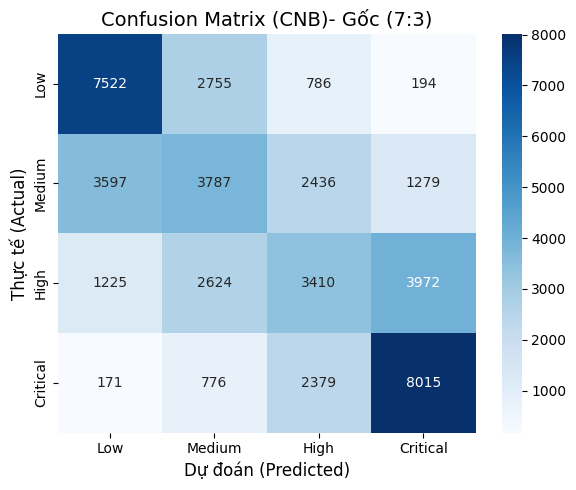

In [ ]:
cm_orig = results_cnb_orig[1]['Confusion Matrix']

plot_confusion_matrix(cm_orig, labels_4_classes, title='Confusion Matrix (CNB)- Gốc (7:3)')

### So sánh các tham số, kiểm tra overfit 

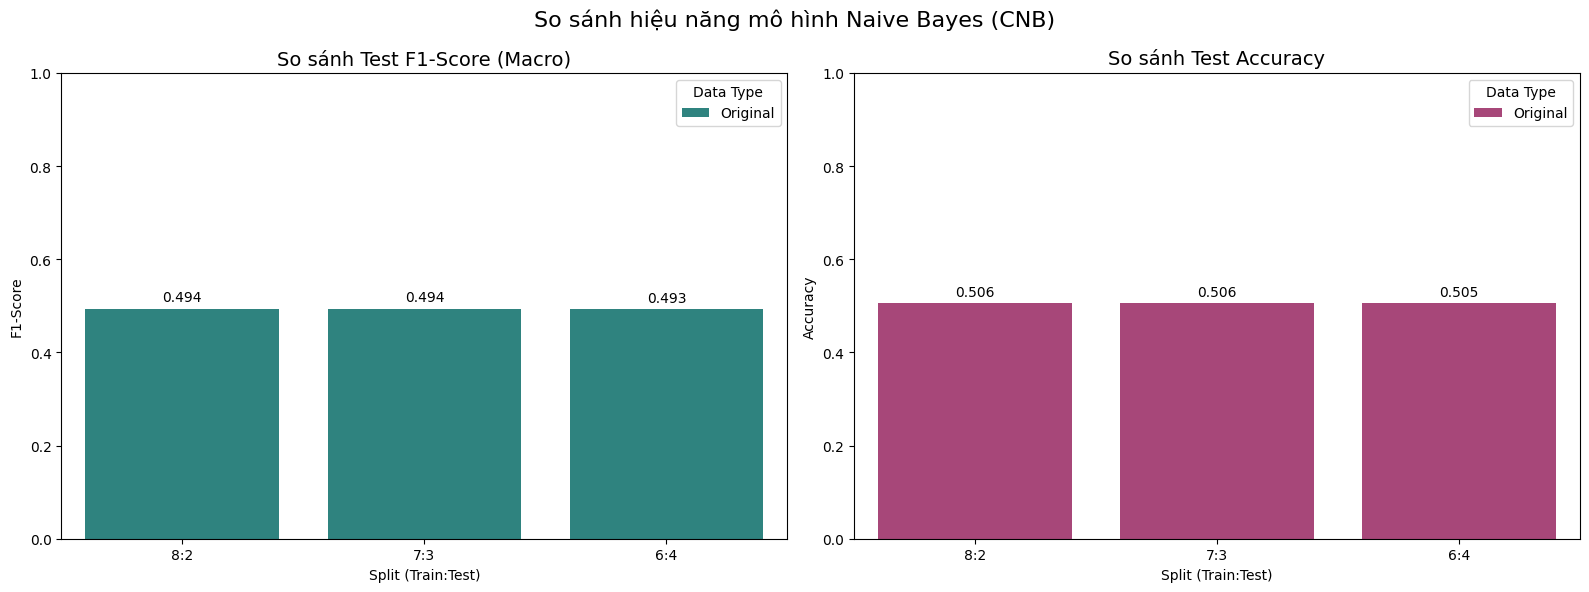

In [ ]:
plot_nb_classification_results(df_cnb_results, 'CNB')

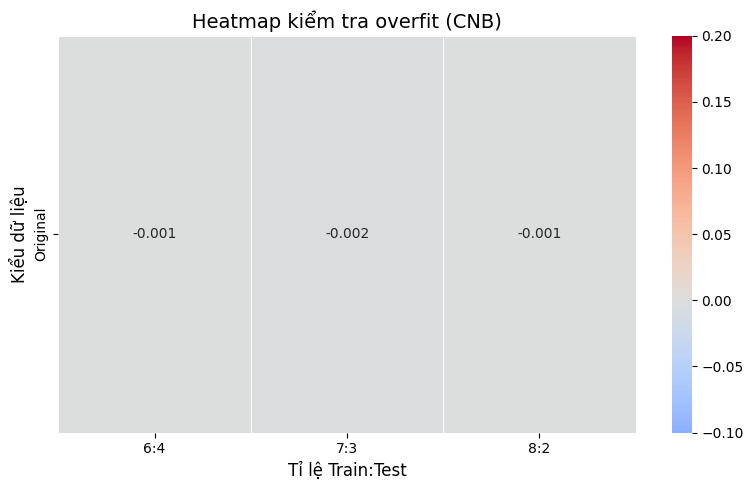

In [ ]:
plot_nb_gap_heatmap(df_cnb_results, 'CNB')

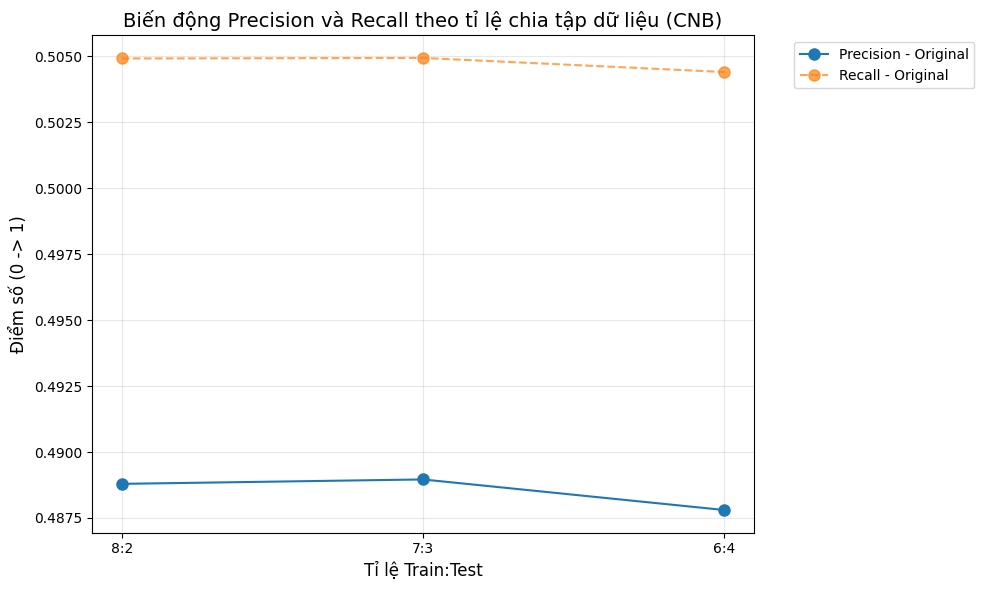

In [ ]:
plot_precision_recall_trends(df_cnb_results, 'CNB')

### Hiệu chỉnh 

In [ ]:
def run_cnb_baseline_with_tuning(X_data: pd.DataFrame, y_data: np.ndarray):
    results = []

    param_grid = {'alpha': [1e-10, 1e-5, 0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0]}

    for split, train_size in split_indices.items():
        split_label = f"{int(split*10)}:{int(10 - split*10)}"

        # 1. Chia train/test
        X_train_raw, X_test_raw, y_train, y_test = train_test_split(
            X_data, y_data,
            train_size=train_size,
            shuffle=False
        )

        # 2. Encode 
        X_train_enc, X_test_enc, bins_used = preprocess_cnb(X_train_raw, X_test_raw)

        # 3. Tinh chỉnh alpha bằng GridSearchCV
        y_train_arr = np.asarray(y_train)

        grid_search = GridSearchCV(
            CategoricalNB(),
            param_grid,
            cv=5,
            scoring='f1_macro',
            n_jobs=-1
        )
        grid_search.fit(X_train_enc, y_train_arr)

        best_model = grid_search.best_estimator_
        best_alpha = grid_search.best_params_['alpha']

        # 4. Dự đoán
        y_train_pred = best_model.predict(X_train_enc)
        y_test_pred  = best_model.predict(X_test_enc)

        # 5. Đánh giá
        train_acc = accuracy_score(y_train_arr, y_train_pred)
        test_acc  = accuracy_score(y_test,      y_test_pred)

        results.append({
            'Data Type':          'Original',
            'Split (Train:Test)': split_label,
            'Best Alpha':         best_alpha,
            'Train Acc':          train_acc,
            'Test Acc':           test_acc,
            'Gap Acc':            train_acc - test_acc,
            'Test Precision':     precision_score(y_test, y_test_pred, average='macro', zero_division=0),
            'Test Recall':        recall_score(y_test, y_test_pred, average='macro', zero_division=0),
            'Test F1':            f1_score(y_test, y_test_pred, average='macro'),
            'Confusion Matrix':   confusion_matrix(y_test, y_test_pred),

            'Model Object':       best_model,
            'X_train_raw':        X_train_raw,
            'X_test_raw':         X_test_raw,
            'X_train_enc':        X_train_enc,
            'X_test_enc':         X_test_enc,
            'y_test_actual':      y_test,
            'y_test_pred':        y_test_pred,
            'y_train_actual':     y_train_arr,
            'y_train_pred':       y_train_pred,
        })

    return results


results_cnb_tuned = run_cnb_baseline_with_tuning(X_raw, y)
df_cnb_results_tuned = pd.DataFrame(results_cnb_tuned)

display(df_cnb_results_tuned.drop(columns=[
    'Confusion Matrix', 'Model Object',
    'X_train_raw', 'X_test_raw', 'X_train_enc', 'X_test_enc',
    'y_test_actual', 'y_test_pred', 'y_train_actual', 'y_train_pred',
]))

,Data Type,Split (Train:Test),Best Alpha,Train Acc,Test Acc,Gap Acc,Test Precision,Test Recall,Test F1
0,Original,8:2,5.000000e-01,0.504351,0.505601,-0.001250,0.488798,0.504919,0.493981
1,Original,7:3,5.000000e-01,0.503883,0.506032,-0.002149,0.488986,0.504963,0.494043
2,Original,6:4,1.000000e-10,0.504064,0.505121,-0.001056,0.487916,0.504474,0.493099


### Trực quan hóa tương quan giữa thực tế và dự đoán

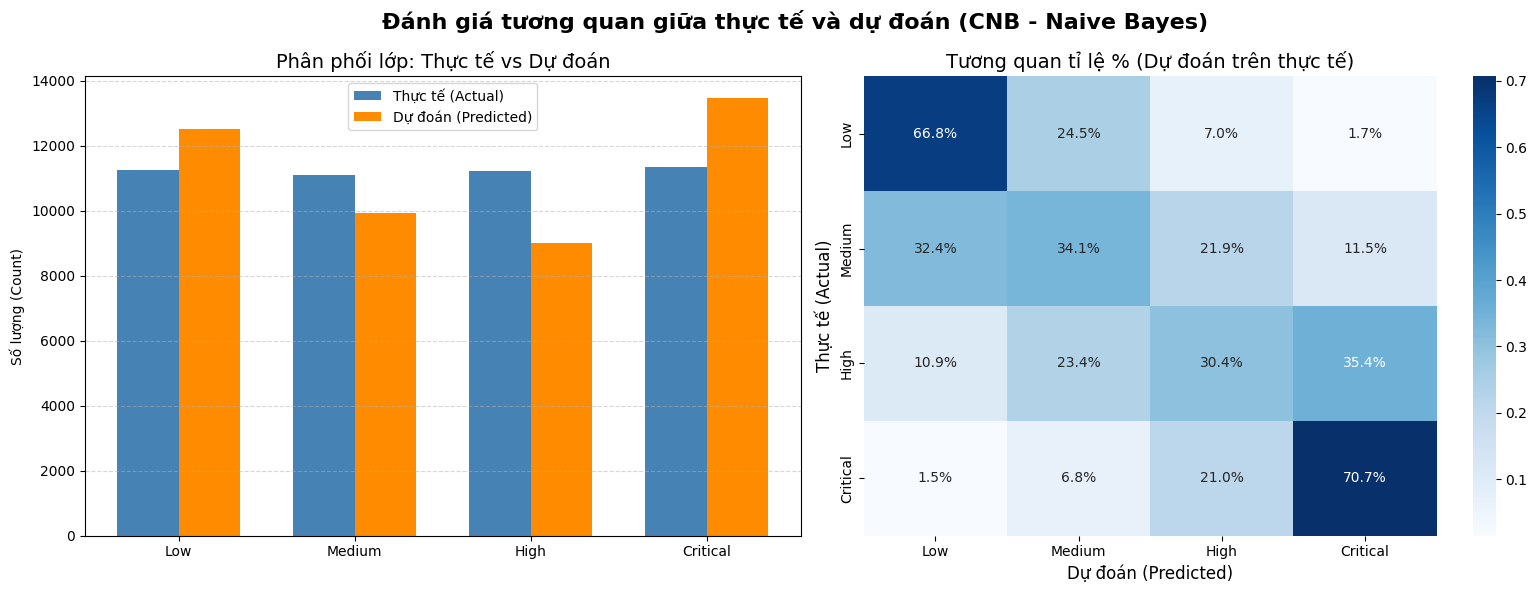

In [ ]:
plot_nb_prediction_analysis(results_cnb_orig, 'CNB')

# Áp dụng mô hình với Mixed Naive Bayes

Tập trung vào dữ liệu gốc do nếu dùng PCA hay truncatedSVD thì sẽ thành số thực => Không dùng được Bernoulli Naive Bayes

### Kết quả mô hình 

In [ ]:
class MixedNaiveBayes(BaseEstimator, ClassifierMixin):
    def __init__(self, var_smoothing=1e-9, alpha=1.0):
        self.var_smoothing = var_smoothing
        self.alpha = alpha

    def fit(self, X_num, X_bern, y):
        self.classes_ = np.unique(y)

        self.gnb_ = GaussianNB(var_smoothing=self.var_smoothing)
        self.bnb_ = BernoulliNB(alpha=self.alpha)

        self.gnb_.fit(X_num, y)
        self.bnb_.fit(X_bern, y)

        class_counts = np.bincount(y.astype(int), minlength=len(self.classes_))
        self.log_prior_ = np.log(class_counts / class_counts.sum())

        self.is_fitted_ = True
        return self

    def predict_log_proba(self, X_num, X_bern):
        log_prior = self.log_prior_
        log_likelihood_num  = self.gnb_.predict_log_proba(X_num)  - log_prior
        log_likelihood_bern = self.bnb_.predict_log_proba(X_bern) - log_prior
        return log_likelihood_num + log_likelihood_bern + log_prior

    def predict(self, X_num, X_bern):
        return self.classes_[np.argmax(self.predict_log_proba(X_num, X_bern), axis=1)]

    def fit_transform_sklearn(self, X, y):
        X_num, X_bern = X
        return self.fit(X_num, X_bern, y)

    def get_params(self, deep=True):
        return {'var_smoothing': self.var_smoothing, 'alpha': self.alpha}

    def set_params(self, **params):
        for k, v in params.items():
            setattr(self, k, v)
        return self

In [ ]:
valid_num_cols = [col for col in (NUMERIC_ORDINAL_COLS + CYCLIC_COLS) if col in X.columns]
valid_bin_cols = [col for col in (ONEHOT_COLS + BINARY_COLS) if col in X.columns]

def run_mixed_nb_default(X_data, y_data):
    results = []

    for split, train_size in split_indices.items():
        split_label = f"{int(split*10)}:{int(10 - split*10)}"

        X_train, X_test, y_train, y_test = train_test_split(
            X_data, y_data, train_size=train_size, shuffle=False
        )

        # Gaussian: chỉ StandardScaler cho numeric + cyclic
        scaler = StandardScaler()
        X_train_num = scaler.fit_transform(X_train[valid_num_cols].astype(float))
        X_test_num  = scaler.transform(X_test[valid_num_cols].astype(float))

        # Bernoulli: one-hot + binary, giữ nguyên 0/1
        X_train_bern = X_train[valid_bin_cols].values.astype(float)
        X_test_bern  = X_test[valid_bin_cols].values.astype(float)

        y_train_arr = y_train.values if hasattr(y_train, 'values') else y_train

        model = MixedNaiveBayes()
        model.fit(X_train_num, X_train_bern, y_train_arr)

        y_train_pred = model.predict(X_train_num, X_train_bern)
        y_test_pred  = model.predict(X_test_num,  X_test_bern)

        train_acc = accuracy_score(y_train_arr, y_train_pred)
        test_acc  = accuracy_score(y_test,      y_test_pred)

        results.append({
            'Data Type':          'Original (Mixed NB - Default)',
            'Split (Train:Test)': split_label,
            'Train Acc':          train_acc,
            'Test Acc':           test_acc,
            'Gap Acc':            train_acc - test_acc,
            'Test Precision':     precision_score(y_test, y_test_pred, average='macro', zero_division=0),
            'Test Recall':        recall_score(y_test, y_test_pred, average='macro', zero_division=0),
            'Test F1':            f1_score(y_test, y_test_pred, average='macro'),
            'Confusion Matrix':   confusion_matrix(y_test, y_test_pred),

            'Model Object':   model,
            'X_train_raw':    X_train,
            'X_test_raw':     X_test,
            'y_test_actual':  y_test,
            'y_test_pred':    y_test_pred,
            'y_train_actual': y_train_arr,
            'y_train_pred':   y_train_pred,
        })

    return results

results_mixnb_orig = run_mixed_nb_default(X, y)
df_mixnb_results   = pd.DataFrame(results_mixnb_orig)
display(df_mixnb_results.drop(columns=[
    'Confusion Matrix', 'Model Object',
    'X_train_raw', 'X_test_raw',
    'y_test_actual', 'y_test_pred', 'y_train_actual', 'y_train_pred'
]))

,Data Type,Split (Train:Test),Train Acc,Test Acc,Gap Acc,Test Precision,Test Recall,Test F1
0,Original (Mixed NB - Default),8:2,0.490512,0.490621,-0.000109,0.468058,0.489957,0.470902
1,Original (Mixed NB - Default),7:3,0.490483,0.490563,-0.000080,0.468660,0.489227,0.471120
2,Original (Mixed NB - Default),6:4,0.489894,0.491777,-0.001882,0.469525,0.490949,0.472306


### Confusion Matrix 

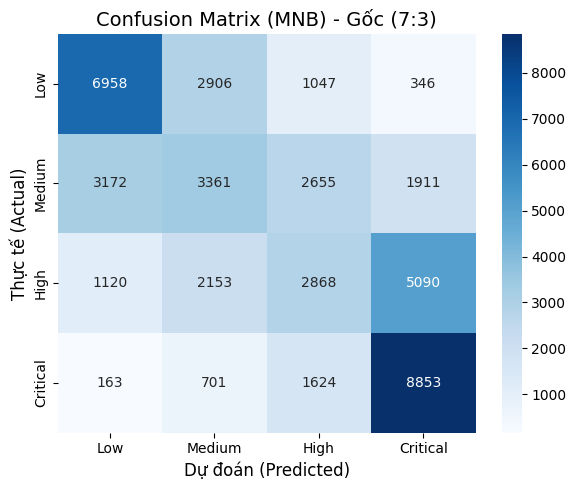

In [ ]:
cm_orig = results_mixnb_orig[1]['Confusion Matrix']

plot_confusion_matrix(cm_orig, labels_4_classes, title='Confusion Matrix (MNB) - Gốc (7:3)')

### So sánh các tham số, kiểm tra overfit 

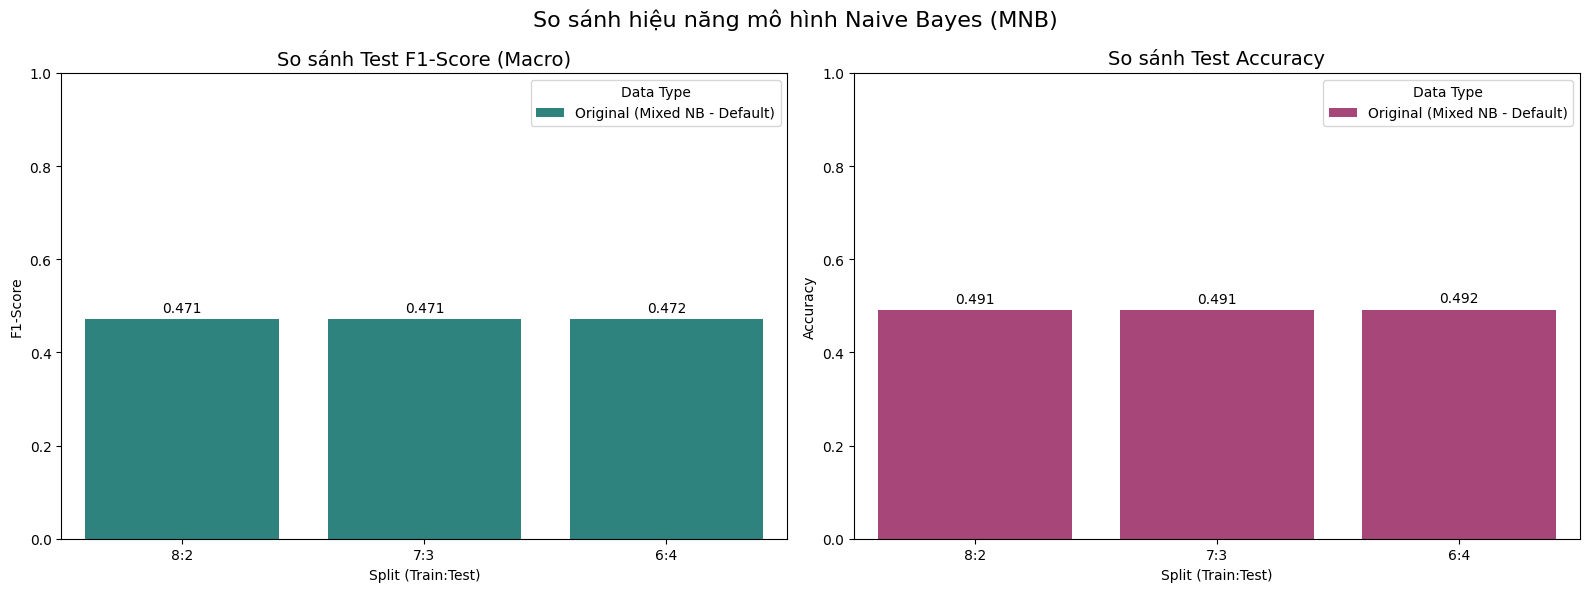

In [ ]:
plot_nb_classification_results(df_mixnb_results, 'MNB')

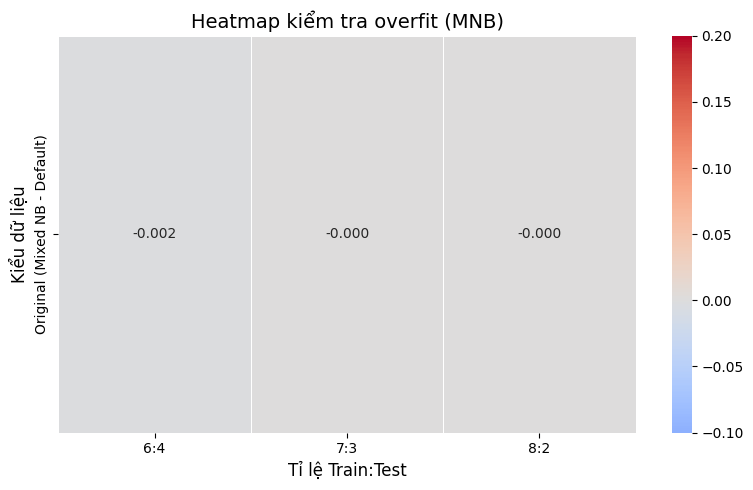

In [ ]:
plot_nb_gap_heatmap(df_mixnb_results, 'MNB')

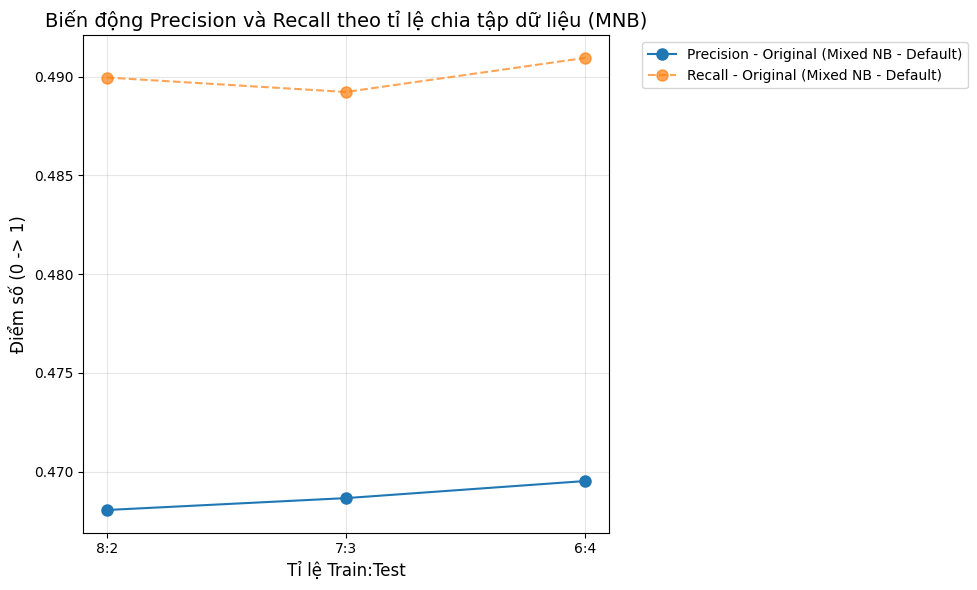

In [ ]:
plot_precision_recall_trends(df_mixnb_results, 'MNB')

### Hiệu chỉnh 

In [ ]:
def run_mixed_nb_tuned(X_data, y_data):
    results = []

    var_smoothing_grid = np.logspace(-10, -1, num=10)
    alpha_grid         = [1e-10, 1e-5, 0.01, 0.1, 1.0, 5.0, 10.0]

    for split, train_size in split_indices.items():
        split_label = f"{int(split*10)}:{int(10 - split*10)}"

        X_train, X_test, y_train, y_test = train_test_split(
            X_data, y_data, train_size=train_size, shuffle=False
        )

        scaler = StandardScaler()
        X_train_num = scaler.fit_transform(X_train[valid_num_cols].astype(float))
        X_test_num  = scaler.transform(X_test[valid_num_cols].astype(float))

        X_train_bern = X_train[valid_bin_cols].values.astype(float)
        X_test_bern  = X_test[valid_bin_cols].values.astype(float)

        y_train_arr = y_train.values if hasattr(y_train, 'values') else y_train

        from sklearn.model_selection import StratifiedKFold
        best_score, best_vs, best_al = -1, 1e-9, 1.0
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

        for vs in var_smoothing_grid:
            for al in alpha_grid:
                fold_scores = []
                for tr_idx, val_idx in skf.split(X_train_num, y_train_arr):
                    m = MixedNaiveBayes(var_smoothing=vs, alpha=al)
                    m.fit(X_train_num[tr_idx], X_train_bern[tr_idx], y_train_arr[tr_idx])
                    preds = m.predict(X_train_num[val_idx], X_train_bern[val_idx])
                    fold_scores.append(f1_score(y_train_arr[val_idx], preds, average='macro'))
                score = np.mean(fold_scores)
                if score > best_score:
                    best_score, best_vs, best_al = score, vs, al

        best_model = MixedNaiveBayes(var_smoothing=best_vs, alpha=best_al)
        best_model.fit(X_train_num, X_train_bern, y_train_arr)

        y_train_pred = best_model.predict(X_train_num, X_train_bern)
        y_test_pred  = best_model.predict(X_test_num,  X_test_bern)

        train_acc = accuracy_score(y_train_arr, y_train_pred)
        test_acc  = accuracy_score(y_test,      y_test_pred)

        results.append({
            'Data Type':          'Original (Mixed NB - Tuned)',
            'Split (Train:Test)': split_label,
            'Best Var Smoothing': best_vs,
            'Best Alpha':         best_al,
            'Train Acc':          train_acc,
            'Test Acc':           test_acc,
            'Gap Acc':            train_acc - test_acc,
            'Test Precision':     precision_score(y_test, y_test_pred, average='macro', zero_division=0),
            'Test Recall':        recall_score(y_test, y_test_pred, average='macro', zero_division=0),
            'Test F1':            f1_score(y_test, y_test_pred, average='macro'),
            'Confusion Matrix':   confusion_matrix(y_test, y_test_pred),

            'Model Object':   best_model,
            'X_train_raw':    X_train,
            'X_test_raw':     X_test,
            'y_test_actual':  y_test,
            'y_test_pred':    y_test_pred,
            'y_train_actual': y_train_arr,
            'y_train_pred':   y_train_pred,
        })

    return results

df_mixed_tuned = pd.DataFrame(run_mixed_nb_tuned(X, y))
display(df_mixed_tuned.drop(columns=[
    'Model Object', 'X_train_raw', 'X_test_raw',
    'y_test_actual', 'y_test_pred', 'y_train_actual', 'y_train_pred', 'Confusion Matrix'
]))

,Data Type,Split (Train:Test),Best Var Smoothing,Best Alpha,Train Acc,Test Acc,Gap Acc,Test Precision,Test Recall,Test F1
0,Original (Mixed NB - Tuned),8:2,1.000000e-03,10.0,0.490520,0.490554,-0.000034,0.467970,0.489890,0.470826
1,Original (Mixed NB - Tuned),7:3,1.000000e-10,1.0,0.490483,0.490563,-0.000080,0.468660,0.489227,0.471120
2,Original (Mixed NB - Tuned),6:4,1.000000e-02,5.0,0.489717,0.491560,-0.001843,0.469386,0.490734,0.472134


### Trực quan hóa tương quan giữa thực tế và dự đoán 

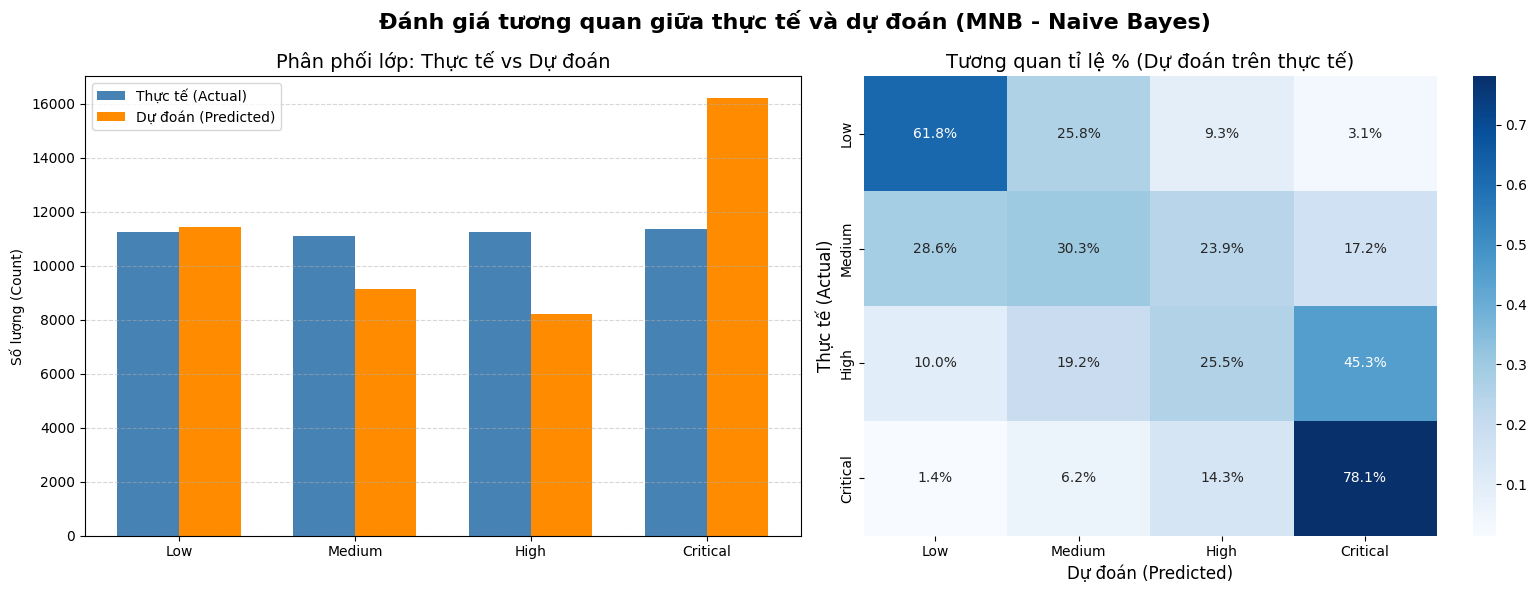

In [ ]:
plot_nb_prediction_analysis(results_mixnb_orig, 'MNB')